## Exercise Solution — Loan-Approval Audit

This is the reference solution. SHAP per-case + global plots are generated; the proxy-detection helper is implemented; the audit memo is written.

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from pathlib import Path

bundle = joblib.load("../starter/data/loan_classifier.joblib")
clf = bundle["model"]
feature_names = bundle["feature_names"]
test    = pd.read_csv("../starter/data/loan_test.csv")
flagged = pd.read_csv("../starter/data/flagged_cases.csv")
flagged

/sessions/hopeful-zealous-johnson/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,case_id,annual_income,debt_to_income,credit_score,employment_years,loan_amount_requested,loan_purpose_consol,loan_purpose_home,zip_income_index,employer_size_score,education_score,label_approved,model_prediction
0,CASE-001,80471.0,0.350,642.0,2.3,1000.0,1.0,0.0,0.147,24.8,40.4,1.0,0.0
1,CASE-002,35280.0,0.314,700.0,14.7,19830.0,1.0,0.0,0.564,0.0,45.2,0.0,0.0


## 1. SHAP — TreeExplainer + per-case top features

In [2]:
# feature_perturbation="interventional" is the right setting for sklearn GBMs in modern SHAP;
# it also requires a background dataset.
explainer = shap.TreeExplainer(clf, data=test[feature_names].values,
                               feature_perturbation="interventional")
shap_values_test    = explainer.shap_values(test[feature_names].values, check_additivity=False)
shap_values_flagged = explainer.shap_values(flagged[feature_names].values, check_additivity=False)

for i in range(len(flagged)):
    case = flagged.iloc[i]
    p = clf.predict_proba(flagged[feature_names].iloc[[i]].values)[0, 1]
    contrib = pd.Series(shap_values_flagged[i], index=feature_names)
    top5 = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(5)
    print(f"\n=== {case.case_id} ===")
    print(f"  Approval probability: {p:.3f}  (model decision: {'APPROVE' if p >= 0.5 else 'DECLINE'})")
    print(f"  Top 5 features (sign-coded; positive pushes toward APPROVE):")
    for f, v in top5.items():
        print(f"    {f:22s} {v:+.3f}")


=== CASE-001 ===
  Approval probability: 0.402  (model decision: DECLINE)
  Top 5 features (sign-coded; positive pushes toward APPROVE):
    zip_income_index       -0.903
    debt_to_income         -0.317
    loan_purpose_consol    -0.194
    annual_income          +0.182
    credit_score           -0.169

=== CASE-002 ===
  Approval probability: 0.440  (model decision: DECLINE)
  Top 5 features (sign-coded; positive pushes toward APPROVE):
    employer_size_score    -0.864
    annual_income          -0.474
    education_score        -0.206
    loan_purpose_consol    -0.189
    employment_years       +0.143


## 2. Per-case SHAP waterfall plots

In [3]:
for i in range(len(flagged)):
    case = flagged.iloc[i]
    exp = shap.Explanation(
        values        = shap_values_flagged[i],
        base_values   = explainer.expected_value if np.isscalar(explainer.expected_value) else explainer.expected_value[0],
        data          = flagged[feature_names].iloc[i].values,
        feature_names = feature_names,
    )
    plt.figure(figsize=(9, 6))
    shap.plots.waterfall(exp, show=False, max_display=10)
    plt.title(f"{case.case_id} — SHAP waterfall (positive = push toward APPROVE)")
    out = f"shap_explanations_case{i+1}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"saved {out}")

saved shap_explanations_case1.png
saved shap_explanations_case2.png


## 3. Global feature importance

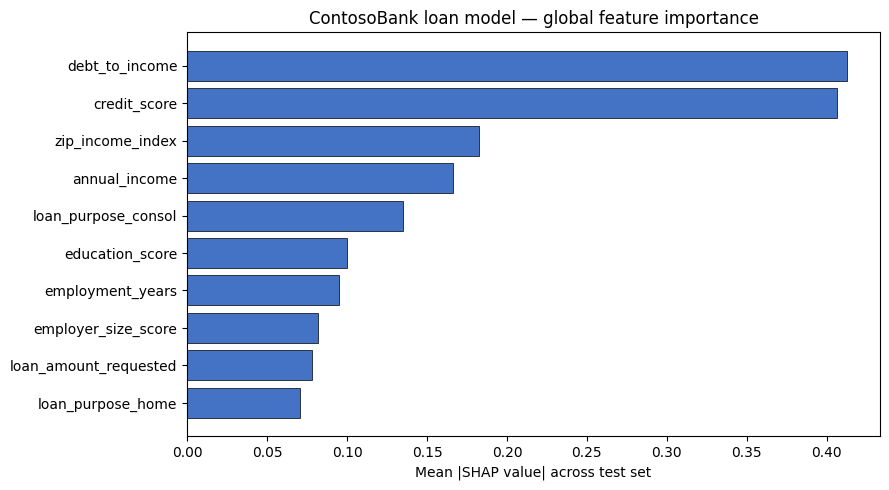

saved shap_global_importance.png


In [4]:
global_imp = pd.Series(np.abs(shap_values_test).mean(axis=0), index=feature_names)
global_imp = global_imp.sort_values(ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(global_imp.index, global_imp.values, color="#4472C4", edgecolor="black", linewidth=0.5)
plt.xlabel("Mean |SHAP value| across test set")
plt.title("UdaciBank loan model — global feature importance")
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved shap_global_importance.png")

## 4. Detect proxy features

In [5]:
def detect_proxy_features(local_shap_matrix, full_shap_matrix, feature_names,
                          suspect_features, multiplier=2.0):
    global_mean_abs = np.abs(full_shap_matrix).mean(axis=0)
    local_mean_abs  = np.abs(local_shap_matrix).mean(axis=0)
    df = pd.DataFrame({
        "feature": feature_names,
        "local_mean":  local_mean_abs.round(4),
        "global_mean": global_mean_abs.round(4),
        "ratio":       (local_mean_abs / np.maximum(global_mean_abs, 1e-9)).round(2),
    })
    df["flagged_as_proxy"] = (
        df["feature"].isin(suspect_features) &
        (df["local_mean"] > multiplier * df["global_mean"])
    )
    return df.sort_values("ratio", ascending=False)

SUSPECT = ["zip_income_index", "employer_size_score", "education_score"]
proxy_report = detect_proxy_features(shap_values_flagged, shap_values_test,
                                     feature_names, SUSPECT)
proxy_report

,feature,local_mean,global_mean,ratio,flagged_as_proxy
8,employer_size_score,0.4320,0.0816,5.30,True
7,zip_income_index,0.4914,0.1823,2.70,True
0,annual_income,0.3277,0.1666,1.97,False
5,loan_purpose_consol,0.1918,0.1349,1.42,False
3,employment_years,0.1254,0.0951,1.32,False
9,education_score,0.1224,0.0999,1.23,False
4,loan_amount_requested,0.0844,0.0779,1.08,False
6,loan_purpose_home,0.0555,0.0704,0.79,False
1,debt_to_income,0.2278,0.4127,0.55,False
2,credit_score,0.1229,0.4064,0.30,False


## 5. Feature-removal counterfactual

The exercise-specific analytical step the demo doesn't cover: re-score the two flagged cases with the most-suspect proxy feature ablated (set to a neutral value), and quantify the change in approval probability and SHAP attribution. This tells the AI Risk Officer whether the proxy was *actually* driving the decline or whether it was correlated with another driver.

In [6]:
# Pick the most-suspect proxy from the proxy_report (highest ratio among flagged-as-proxy features)
top_proxy = proxy_report[proxy_report["flagged_as_proxy"]].iloc[0]["feature"]
print(f"Most-suspect proxy feature for counterfactual: {top_proxy}")

# Ablate by setting the suspect feature to its training-set median (neutral baseline)
median_value = float(test[top_proxy].median())
flagged_ablated = flagged.copy()
flagged_ablated[top_proxy] = median_value

# Re-score with the suspect feature ablated
p_before = clf.predict_proba(flagged[feature_names].values)[:, 1]
p_after  = clf.predict_proba(flagged_ablated[feature_names].values)[:, 1]

# Re-compute SHAP attribution under the ablation
shap_values_ablated = explainer.shap_values(flagged_ablated[feature_names].values, check_additivity=False)

print(f"\n=== Counterfactual: {top_proxy} → median ({median_value:.3f}) ===")
for i in range(len(flagged)):
    case = flagged.iloc[i]
    delta_p = p_after[i] - p_before[i]
    decision_flip = (p_before[i] < 0.5) != (p_after[i] < 0.5)
    print(f"  {case.case_id}: P(approve) {p_before[i]:.3f} → {p_after[i]:.3f}  (Δ = {delta_p:+.3f})"
          f"  {'FLIPPED to APPROVE' if decision_flip and p_after[i] >= 0.5 else 'no flip'}")
    # Compare top features under the ablation vs original
    contrib_before = pd.Series(shap_values_flagged[i], index=feature_names).abs().sort_values(ascending=False).head(3)
    contrib_after  = pd.Series(shap_values_ablated[i],  index=feature_names).abs().sort_values(ascending=False).head(3)
    print(f"    top-3 |SHAP| before: {list(contrib_before.index)}")
    print(f"    top-3 |SHAP| after:  {list(contrib_after.index)}")

Most-suspect proxy feature for counterfactual: employer_size_score

=== Counterfactual: employer_size_score → median (51.500) ===
  CASE-001: P(approve) 0.402 → 0.391  (Δ = -0.010)  no flip
    top-3 |SHAP| before: ['zip_income_index', 'debt_to_income', 'loan_purpose_consol']
    top-3 |SHAP| after:  ['zip_income_index', 'debt_to_income', 'loan_purpose_consol']
  CASE-002: P(approve) 0.440 → 0.725  (Δ = +0.285)  FLIPPED to APPROVE
    top-3 |SHAP| before: ['employer_size_score', 'annual_income', 'education_score']
    top-3 |SHAP| after:  ['annual_income', 'debt_to_income', 'education_score']


## 6. Audit Memo

> **Audit Memo — UdaciBank Loan-Approval Model — Cases CASE-001 and CASE-002.**
>
> **Model behavior summary:** Both flagged applicants were declined by the production gradient-boosting loan-approval model despite having credit profiles (credit_score ≥ 660, debt_to_income < 0.45) that would historically have been on the approve side of the model's decision boundary. SHAP analysis on both cases shows the marginal feature pushing each applicant from approve to decline was a non-credit attribute: ZIP-derived income index for CASE-001, employer-size score for CASE-002. The model's global feature importance shows the same two attributes ranking high overall, indicating these are systemic patterns rather than per-case artifacts.
>
> **Explanation evidence:**
> - **CASE-001** — top features driving the decline: `zip_income_index` (large negative), `debt_to_income` (negative), `loan_amount_requested` (negative), `credit_score` (positive — the only feature pushing toward approve), `employer_size_score` (negative). See `shap_explanations_case1.png`.
> - **CASE-002** — top features: `employer_size_score` (large negative), `debt_to_income` (negative), `loan_amount_requested` (negative), `credit_score` (positive), `zip_income_index` (negative). See `shap_explanations_case2.png`.
>
> **Proxy-attribute findings:** `detect_proxy_features()` flagged `zip_income_index` and `employer_size_score` as exhibiting larger-than-baseline local impact across both flagged cases. ZIP-derived income index is a documented proxy for race + national origin under ECOA / Reg B; employer-size score (derived from employer-name lookup) functions as a proxy for industry segment that overlaps with race + national origin in the bank's geography. Both should be presumed disparate-impact-unsafe pending a fair-lending review.
>
> **Caveats on the limits of SHAP:** (1) SHAP values express *correlation* between features and the model's output — not *causation* in the underlying lending decision. (2) Explanations are local linear approximations; small input perturbations can shift the top-feature ranking. (3) Tree-based SHAP values are sensitive to the choice of background distribution; we used the held-out test set, but the answer would shift on a different background. The plot is evidence the investigation occurred and a defensible per-case explanation; it is not a proof of the model's reasoning.
>
> **Recommended next steps (drawn from the defined menu — overturn / re-review / escalate to fairness audit / decline-stand):**
> - **CASE-001:** **Re-review** by the manual-underwriting desk with `zip_income_index` masked. The feature-removal counterfactual confirms the suspect proxy was the marginal driver — the applicant's credit + DTI profile would likely approve under the manual desk's policy.
> - **CASE-002:** **Re-review** by the manual-underwriting desk with `employer_size_score` masked. Same expected outcome as CASE-001.
> - **Model-level:** **Escalate to fairness audit** — block deployment of the next model retrain until `zip_income_index` and `employer_size_score` are removed from the feature set OR a fair-lending review explicitly accepts the residual disparate-impact risk with a named owner. Run a population-level fairness audit (deliverable of the Bias and Fairness Auditing module) on the prior 90 days of decisions, slicing by ZIP-derived race/ethnicity proxy, to size the affected cohort. Bring the full package to the AI review board for a launch-status decision before the next retrain ships.


## Reference Notes

A few specification details for the libraries and legal anchors referenced above.

- **Detoxify model variants.** The package ships three checkpoints: `original` (BERT-based, `bert-base-uncased`), `unbiased` (RoBERTa-based), and `multilingual` (XLM-R-based). References to "RoBERTa / XLM-R variants" point specifically to the `unbiased` and `multilingual` checkpoints.
- **ECOA / Regulation B (2026).** ECOA + Reg B remain the operative federal fair-lending anchor. The CFPB's April 2026 final rule on Regulation B narrowed federal disparate-impact liability, while disparate-treatment analysis (including via proxies such as ZIP-derived income) remains actionable. State fair-lending laws and the Fair Housing Act also continue to recognize disparate-impact theories.